# Разведочный анализ данных (EDA)

Данные содержат молекулярные дескрипторы химических соединений и три целевые переменные:
- **IC50** — концентрация вещества, при которой подавляется 50% активности (мМ)
- **CC50** — цитотоксическая концентрация 50% (мМ)
- **SI** — индекс селективности = CC50 / IC50

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Загрузка данных

In [17]:
# Укажите путь к файлу
DATA_PATH = 'Данные_для_курсовои_Классическое_МО.csv'

df = pd.read_csv(DATA_PATH, sep=';', decimal=',')

# Убираем технический индекс
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS]

print(f'Размер датасета: {df.shape}')
print(f'Целевые переменные: {TARGET_COLS}')
print(f'Количество признаков: {len(FEATURE_COLS)}')

Размер датасета: (1001, 213)
Целевые переменные: ['IC50, mM', 'CC50, mM', 'SI']
Количество признаков: 210


## 2. Общая информация о датасете

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


In [19]:
# Проверка пропущенных значений
missing = df.isnull().sum()
print('Пропущенные значения:')
print(missing[missing > 0] if missing.any() else 'Пропущенных значений нет')

Пропущенные значения:
MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64


## 3. Описательная статистика целевых переменных

In [20]:
target_stats = df[TARGET_COLS].describe().T
target_stats['median'] = df[TARGET_COLS].median()
target_stats['skew']   = df[TARGET_COLS].skew()
target_stats['kurt']   = df[TARGET_COLS].kurtosis()
print(target_stats.round(3))

             count     mean      std    min     25%      50%      75%  \
IC50, mM 1001.0000 222.8050 402.1700 0.0040 12.5150  46.5850 224.9760   
CC50, mM 1001.0000 589.1110 642.8680 0.7010 99.9990 411.0390 894.0890   
SI       1001.0000  72.5090 684.4830 0.0110  1.4330   3.8460  16.5670   

                max   median    skew     kurt  
IC50, mM  4128.5290  46.5850  3.6750  22.4500  
CC50, mM  4538.9760 411.0390  1.9730   5.6790  
SI       15620.6000   3.8460 18.0130 361.4170  


**Вывод:** Все три переменные имеют выраженную правостороннюю асимметрию (skew >> 0),
что характерно для биологических данных. Это означает, что при регрессии может потребоваться
логарифмическое преобразование целевой переменной.

## 4. Распределение целевых переменных

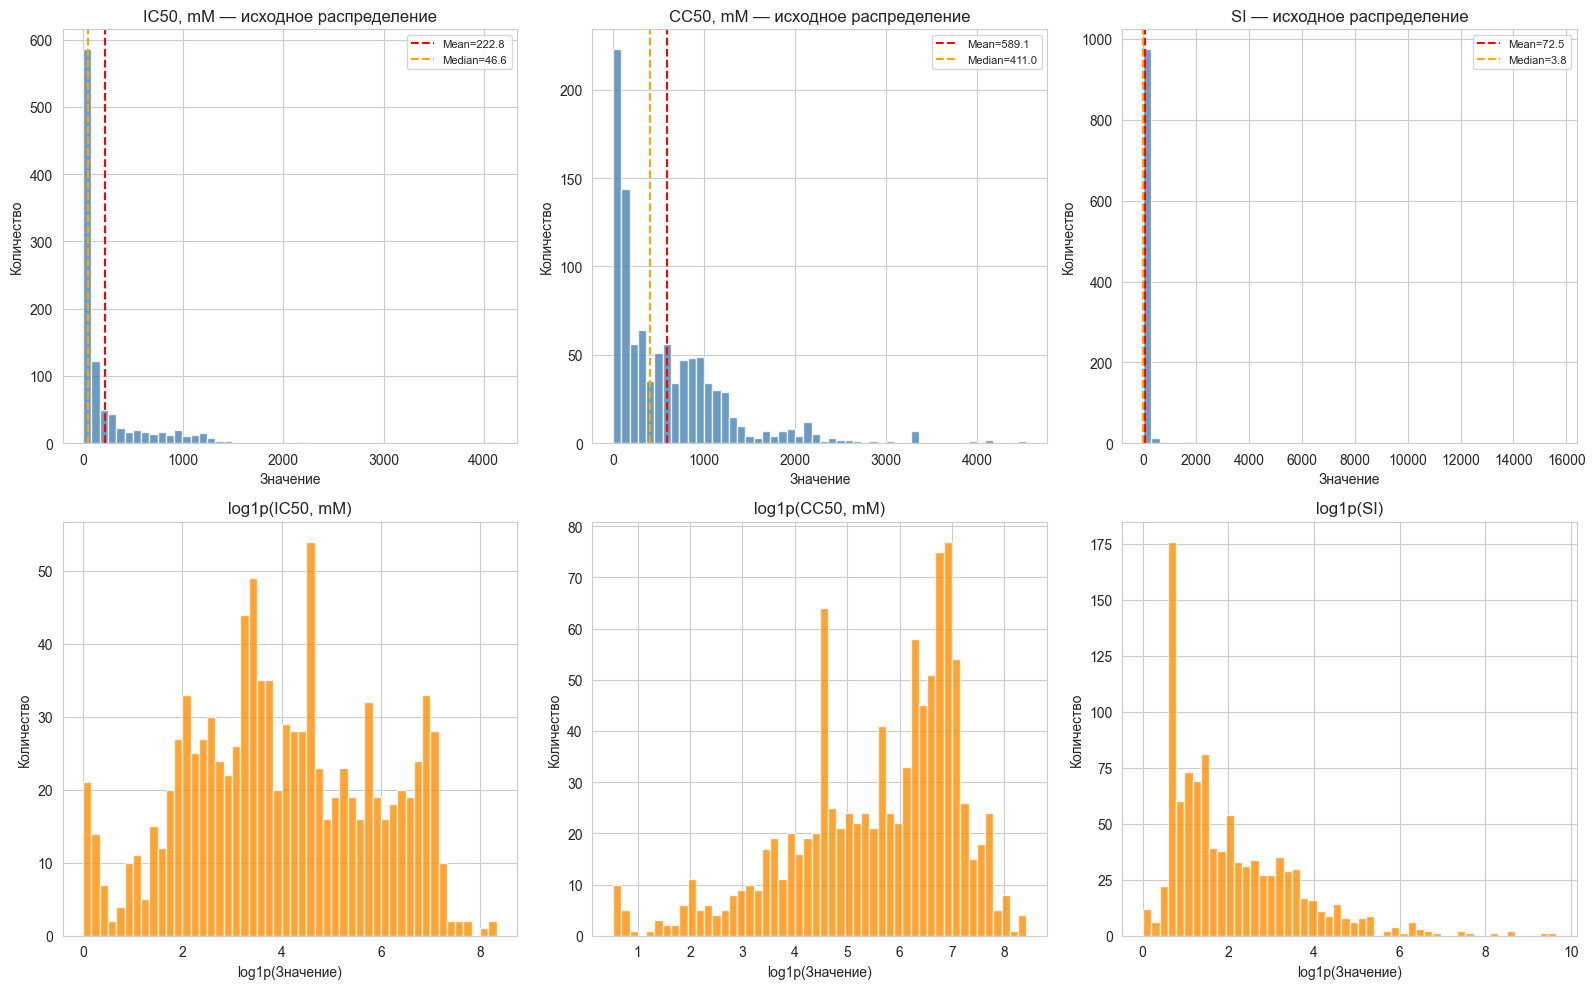

График сохранён: target_distributions.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(TARGET_COLS):
    # Исходное распределение
    ax = axes[0, i]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.1f}')
    ax.set_title(f'{col} — исходное распределение')
    ax.legend(fontsize=8)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Количество')

    # Логарифмическое распределение
    ax2 = axes[1, i]
    log_vals = np.log1p(df[col])
    ax2.hist(log_vals, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
    ax2.set_title(f'log1p({col})')
    ax2.set_xlabel('log1p(Значение)')
    ax2.set_ylabel('Количество')

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: target_distributions.png')

## 5. Корреляция между целевыми переменными

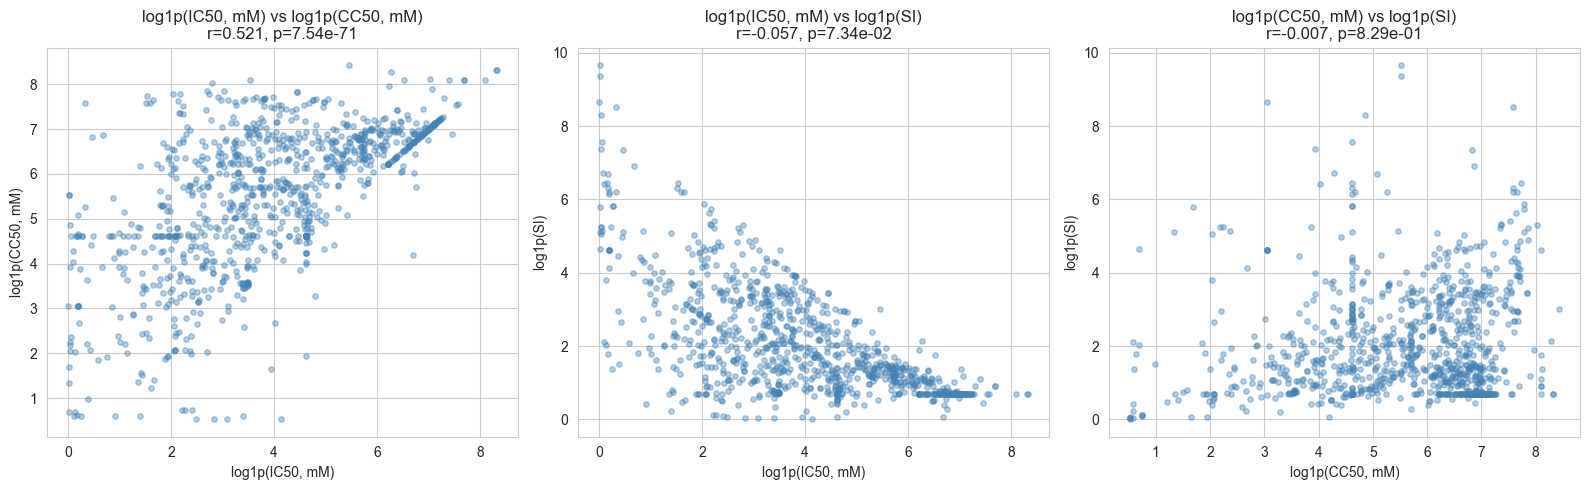

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('IC50, mM', 'CC50, mM'), ('IC50, mM', 'SI'), ('CC50, mM', 'SI')]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(np.log1p(df[x]), np.log1p(df[y]), alpha=0.4, s=15, color='steelblue')
    r, p = stats.pearsonr(df[x], df[y])
    ax.set_title(f'log1p({x}) vs log1p({y})\nr={r:.3f}, p={p:.2e}')
    ax.set_xlabel(f'log1p({x})')
    ax.set_ylabel(f'log1p({y})')

plt.tight_layout()
plt.savefig('target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Выявление выбросов (IQR-метод) в целевых переменных

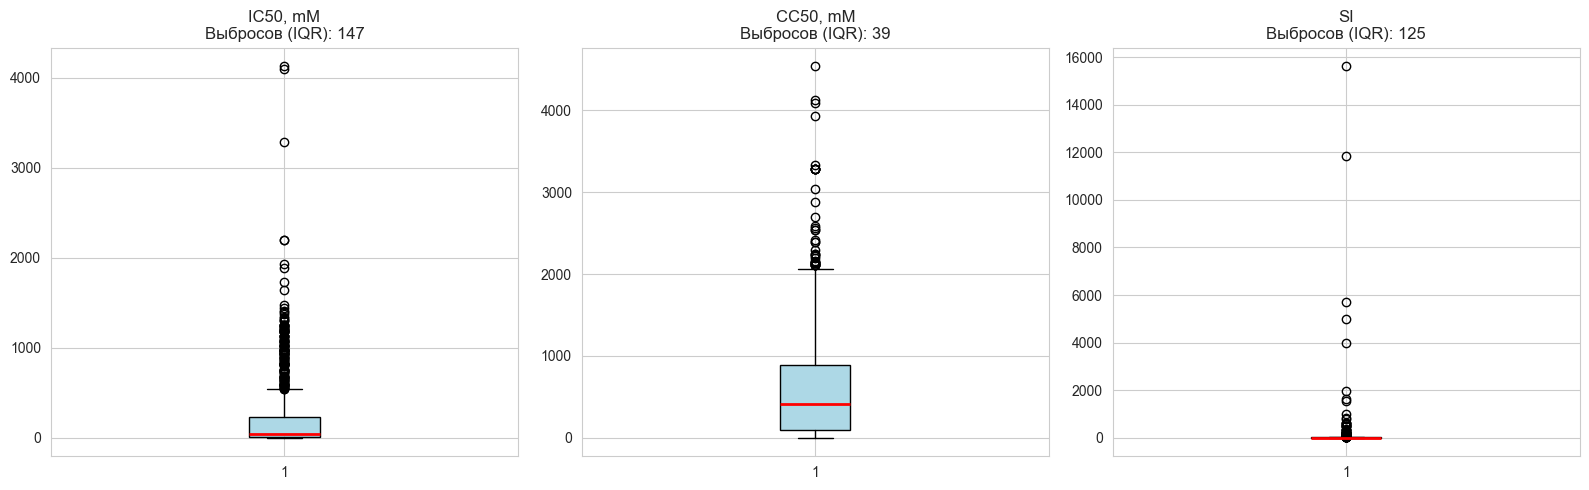

IC50, mM: выбросов 147 (14.7%)
CC50, mM: выбросов 39 (3.9%)
SI: выбросов 125 (12.5%)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, TARGET_COLS):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\nВыбросов (IQR): {n_out}')

plt.tight_layout()
plt.savefig('target_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Статистика выбросов
for col in TARGET_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: выбросов {n_out} ({n_out/len(df)*100:.1f}%)')

## 7. Анализ признаков — описательная статистика

In [24]:
feat_stats = df[FEATURE_COLS].describe().T
feat_stats['zero_frac'] = (df[FEATURE_COLS] == 0).mean()
feat_stats['variance']  = df[FEATURE_COLS].var()

# Признаки с нулевой дисперсией (константы)
zero_var = feat_stats[feat_stats['std'] == 0]
print(f'Признаков с нулевой дисперсией: {len(zero_var)}')
if len(zero_var):
    print(zero_var.index.tolist())

Признаков с нулевой дисперсией: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


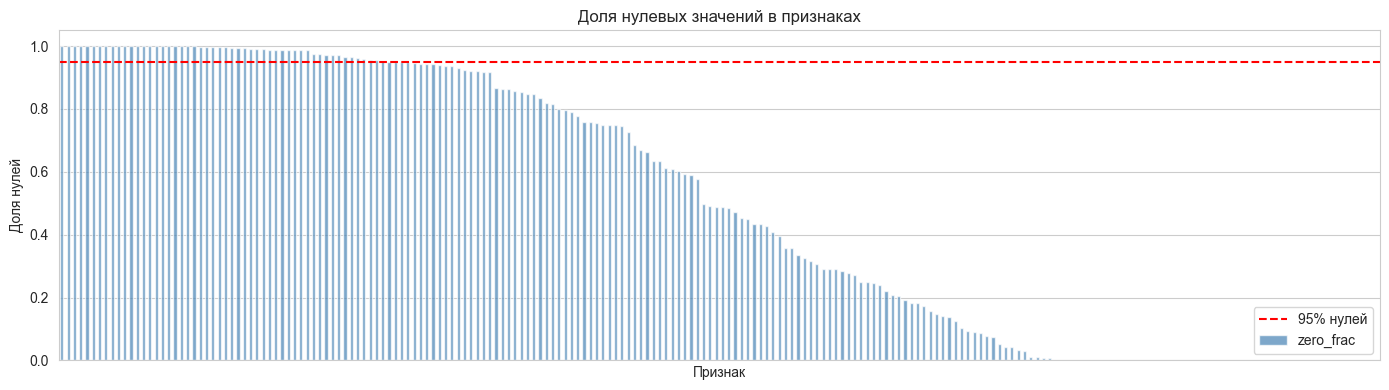

Признаков с >95% нулей: 53


In [25]:
# Доля нулевых значений в признаках
zero_fracs = feat_stats['zero_frac'].sort_values(ascending=False)

plt.figure(figsize=(14, 4))
zero_fracs.plot(kind='bar', color='steelblue', alpha=0.7)
plt.axhline(0.95, color='red', linestyle='--', label='95% нулей')
plt.title('Доля нулевых значений в признаках')
plt.xlabel('Признак')
plt.ylabel('Доля нулей')
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.savefig('feature_zeros.png', dpi=150, bbox_inches='tight')
plt.show()

# Признаки, где более 95% значений — нули
sparse_features = zero_fracs[zero_fracs > 0.95].index.tolist()
print(f'Признаков с >95% нулей: {len(sparse_features)}')

## 8. Корреляция признаков с целевыми переменными

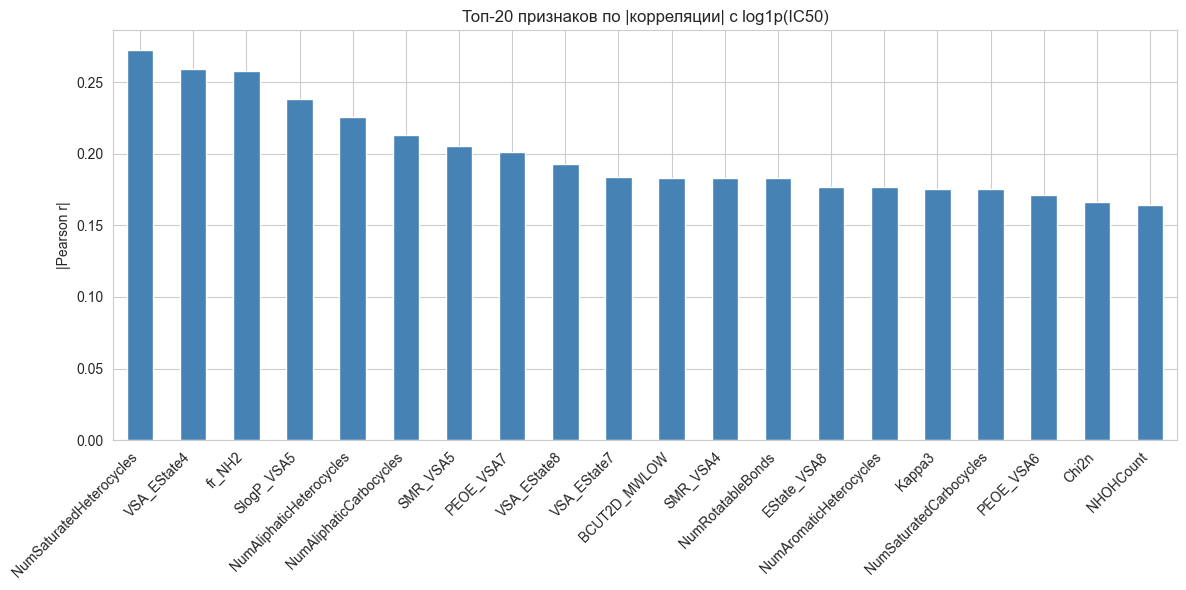

Топ-10 признаков по корреляции с IC50:
NumSaturatedHeterocycles   0.2730
VSA_EState4                0.2590
fr_NH2                     0.2580
SlogP_VSA5                 0.2380
NumAliphaticHeterocycles   0.2260
NumAliphaticCarbocycles    0.2130
SMR_VSA5                   0.2050
PEOE_VSA7                  0.2010
VSA_EState8                0.1930
VSA_EState7                0.1840
Name: IC50, mM, dtype: float64


In [26]:
# Pearson-корреляция признаков с log1p(target)
corr_results = {}
for col in TARGET_COLS:
    target_log = np.log1p(df[col])
    corrs = df[FEATURE_COLS].apply(lambda x: target_log.corr(x))
    corr_results[col] = corrs

corr_df = pd.DataFrame(corr_results)

# Топ-20 признаков по абсолютной корреляции с IC50
top20_ic50 = corr_df['IC50, mM'].abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top20_ic50.plot(kind='bar', color='steelblue')
plt.title('Топ-20 признаков по |корреляции| с log1p(IC50)')
plt.ylabel('|Pearson r|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top20_features_IC50.png', dpi=150, bbox_inches='tight')
plt.show()

print('Топ-10 признаков по корреляции с IC50:')
print(corr_df['IC50, mM'].abs().sort_values(ascending=False).head(10).round(3))

## 9. Тепловая карта корреляций (топ-30 признаков)

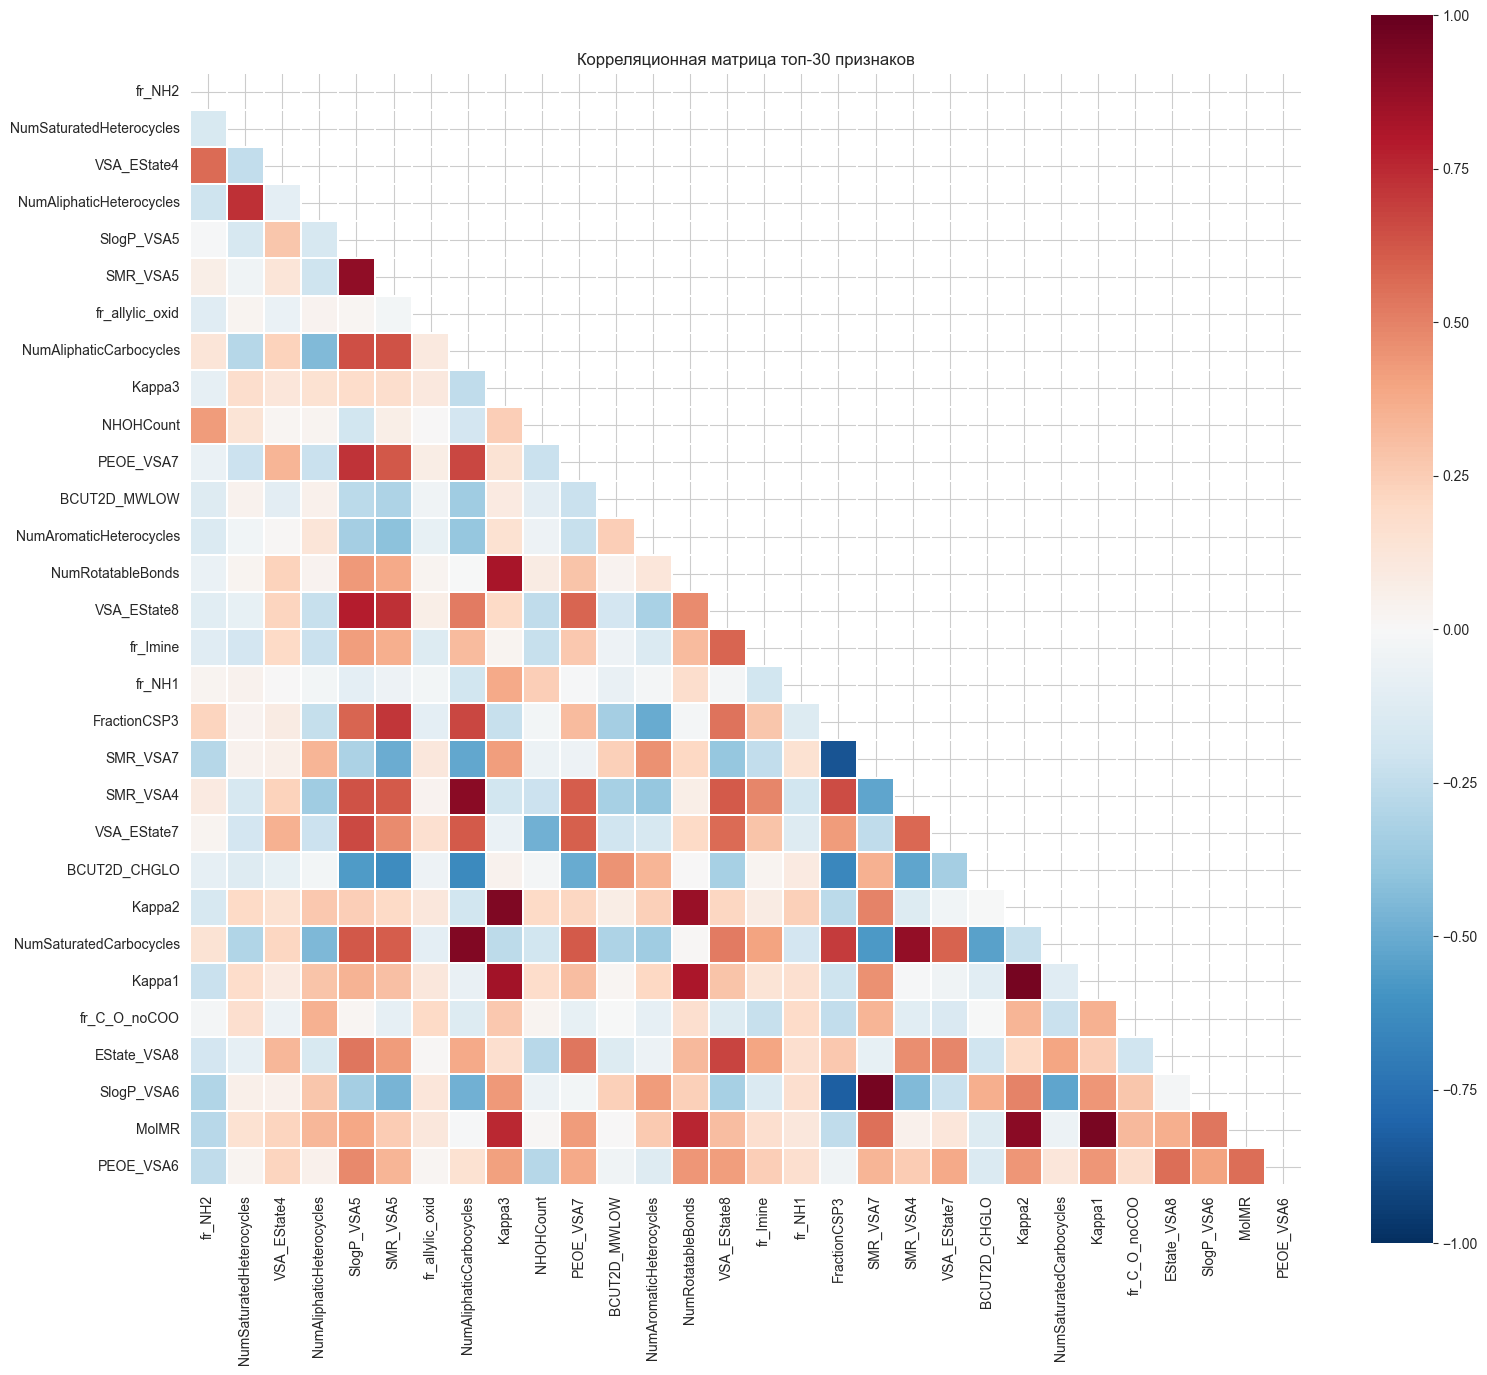

In [27]:
# Выбираем топ-30 признаков по суммарной корреляции со всеми таргетами
top_feats = corr_df.abs().sum(axis=1).sort_values(ascending=False).head(30).index.tolist()

corr_matrix = df[top_feats].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, annot=False
)
plt.title('Корреляционная матрица топ-30 признаков')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Анализ бинарных признаков-меток классификации

Медиана IC50 = 46.5852 мМ
Медиана CC50 = 411.0393 мМ
Медиана SI   = 3.8462



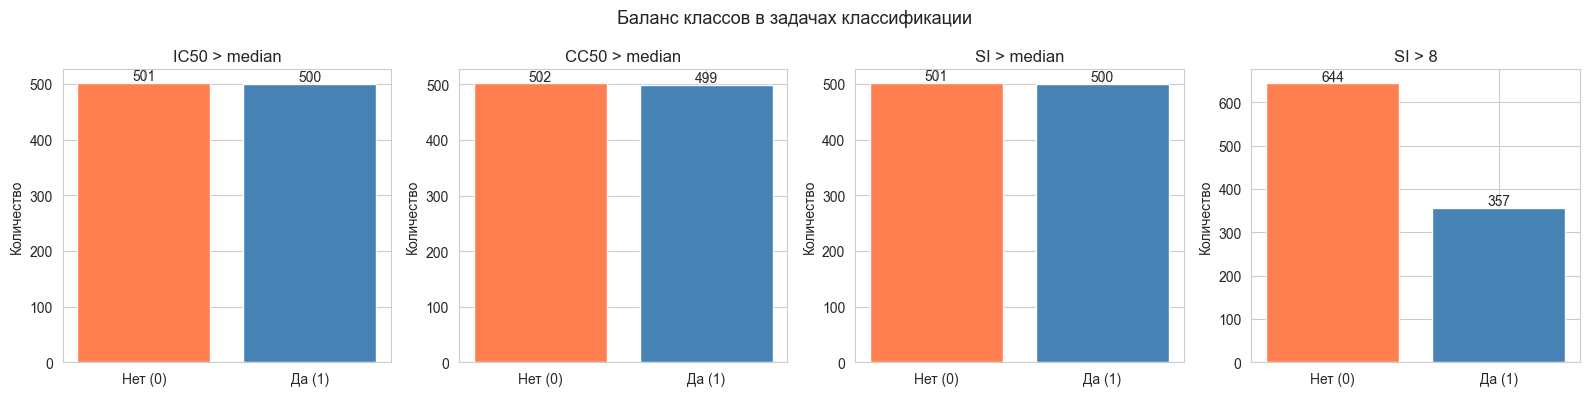

IC50 > median: класс 1 = 500 (50.0%), класс 0 = 501 (50.0%)
CC50 > median: класс 1 = 499 (49.9%), класс 0 = 502 (50.1%)
SI > median: класс 1 = 500 (50.0%), класс 0 = 501 (50.0%)
SI > 8: класс 1 = 357 (35.7%), класс 0 = 644 (64.3%)


In [28]:
# Медианы целевых переменных и порог SI=8
medians = df[TARGET_COLS].median()

df['y_IC50_gt_median'] = (df['IC50, mM'] > medians['IC50, mM']).astype(int)
df['y_CC50_gt_median'] = (df['CC50, mM'] > medians['CC50, mM']).astype(int)
df['y_SI_gt_median']   = (df['SI']       > medians['SI']).astype(int)
df['y_SI_gt_8']        = (df['SI']       > 8).astype(int)

print(f"Медиана IC50 = {medians['IC50, mM']:.4f} мМ")
print(f"Медиана CC50 = {medians['CC50, mM']:.4f} мМ")
print(f"Медиана SI   = {medians['SI']:.4f}")
print()

clf_targets = ['y_IC50_gt_median', 'y_CC50_gt_median', 'y_SI_gt_median', 'y_SI_gt_8']
clf_labels  = [
    'IC50 > median', 'CC50 > median',
    'SI > median',   'SI > 8'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, label in zip(axes, clf_targets, clf_labels):
    counts = df[col].value_counts().sort_index()
    ax.bar(['Нет (0)', 'Да (1)'], counts.values, color=['coral', 'steelblue'])
    ax.set_title(label)
    ax.set_ylabel('Количество')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 5, str(v), ha='center', fontsize=10)

plt.suptitle('Баланс классов в задачах классификации', fontsize=13)
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

for col, label in zip(clf_targets, clf_labels):
    pos = df[col].sum()
    print(f'{label}: класс 1 = {pos} ({pos/len(df)*100:.1f}%), класс 0 = {len(df)-pos} ({(len(df)-pos)/len(df)*100:.1f}%)')

## 11. Анализ мультиколлинеарности признаков

In [29]:
from sklearn.preprocessing import StandardScaler

# Полная матрица корреляций признаков
feat_corr = df[FEATURE_COLS].corr().abs()

# Верхний треугольник
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))

# Признаки, высоко коррелированные с другими (порог 0.95)
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Признаков с попарной корреляцией > 0.95: {len(high_corr)}')
print('Такие признаки можно удалить без существенной потери информации.')

Признаков с попарной корреляцией > 0.95: 33
Такие признаки можно удалить без существенной потери информации.


## 12. Сохранение обработанного датасета

In [30]:
# Удаляем признаки с нулевой дисперсией
zero_var_cols = [c for c in FEATURE_COLS if df[c].std() == 0]
df_clean = df.drop(columns=zero_var_cols)
print(f'Удалено признаков с нулевой дисперсией: {len(zero_var_cols)}')

# Сохраняем
df_clean.to_csv('data_clean.csv', index=False)
print(f'Сохранён файл data_clean.csv, размер: {df_clean.shape}')

print('\n=== Итоги EDA ===')
print(f'Объём выборки: {len(df)} объектов')
print(f'Признаков после очистки: {len([c for c in df_clean.columns if c not in TARGET_COLS+clf_targets])}')
print(f'Все три таргета имеют правостороннюю асимметрию → рекомендуется log-преобразование при регрессии')
print(f'Пропущенных значений нет')
print(f'Высококоррелированных признаков (>0.95): {len(high_corr)} — будут отфильтрованы в моделях')

Удалено признаков с нулевой дисперсией: 18
Сохранён файл data_clean.csv, размер: (1001, 199)

=== Итоги EDA ===
Объём выборки: 1001 объектов
Признаков после очистки: 192
Все три таргета имеют правостороннюю асимметрию → рекомендуется log-преобразование при регрессии
Пропущенных значений нет
Высококоррелированных признаков (>0.95): 33 — будут отфильтрованы в моделях
